# 01d — Temporal Split EDA
Parse `Time_Date`, visualize time distribution, and create chronological splits.

In [1]:
import os
from pathlib import Path

# Find project root (contains pyproject.toml)
root = Path.cwd()
while not (root / "pyproject.toml").exists():
    root = root.parent
os.chdir(root)
print(f"Working directory: {root}")

Working directory: e:\OSFDA


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from src.utils.config import load_main_config, resolve_path
from src.data.loader import load_raw_data, parse_time_date
from src.features.temporal import create_temporal_split, validate_temporal_split

config = load_main_config()
df = load_raw_data(config)
df = parse_time_date(df)
print(f'Loaded {len(df)} records.')
print(f"Year range: {df['year'].min()} to {df['year'].max()}")

Loaded 38655 records from E:\OSFDA\data\raw\asrs_full.parquet
Loaded 38655 records.
Year range: 2012 to 2022


## 1. Reports per Year

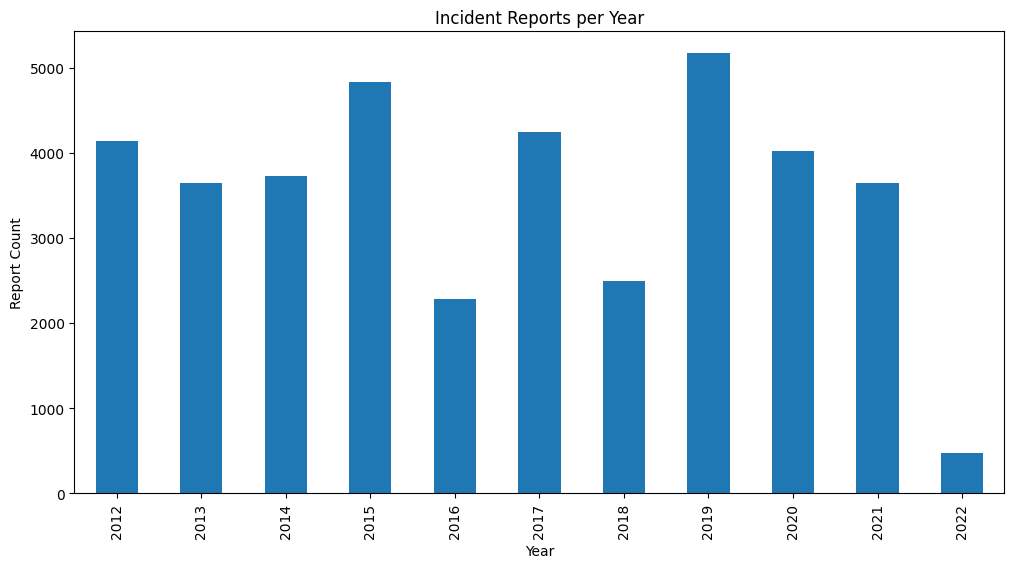

In [3]:
plt.figure(figsize=(12, 6))
df['year'].value_counts().sort_index().plot(kind='bar')
plt.title('Incident Reports per Year')
plt.xlabel('Year')
plt.ylabel('Report Count')
plt.show()

## 2. Create and Validate Splits

In [4]:
df = create_temporal_split(df)
split_info = validate_temporal_split(df)

for s in ['train', 'val', 'test']:
    info = split_info[s]
    print(f"{s}: {info['count']} ({info['pct']}%) — years {info['year_min']}-{info['year_max']}")
print(f"\nValid (no overlap): {split_info['is_valid']}")

train: 22854 (59.1%) — years 2012-2017
val: 2492 (6.4%) — years 2018-2018
test: 13309 (34.4%) — years 2019-2022

Valid (no overlap): True


## 3. Save Split Assignments

In [5]:
split_path = resolve_path('data/processed/temporal_splits.parquet')
df[['acn_num_ACN', 'year', 'month', 'split']].to_parquet(split_path, index=False)
print(f'Temporal splits saved to {split_path}')

Temporal splits saved to E:\OSFDA\data\processed\temporal_splits.parquet
